In [1]:
import sys
!{sys.executable} -m pip install numpy
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install pandas
!{sys.executable} -m pip install seaborn
!{sys.executable} -m pip install scipy
!{sys.executable} -m pip install scikit-learn

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.patches as mpatches
import datetime

In [3]:
print(datetime.datetime.now())

2026-08-03 22:20:24.674917


In [4]:
valid_words = []

file_path = '../small.txt'

with open(file_path, 'r') as file:
    for line in file:
        sline = line.strip()
        valid_words.append(sline)

print(len(valid_words))

7699


### preprocessing word list to see if it'll make things faster

In [5]:
import string

alphabet = list(string.ascii_lowercase)
valid_words_by_first_letter = {}
for a in alphabet:
    valid_words_by_first_letter[a] = []

In [6]:
for v in valid_words:
    valid_words_by_first_letter[v[0]].append(v)

In [7]:
def get_possible_word_scores(letter_set):
	set_count = {}
	for c1 in letter_set:
		if c1 in set_count:
			set_count[c1] += 1
		else:
			set_count[c1] = 1
	
	possible_word_scores = {}
	for word in valid_words:
		word_count = {}
		word_possible = True
    
		for c2 in word:
			if c2 not in set_count:
				word_possible = False
				break
			elif c2 in word_count:
				word_count[c2] += 1
			else:
				word_count[c2] = 1
		
		if not word_possible:
			continue

		word_possible = True
		for w in word_count:
			if w not in set_count:
				word_possible = False
				break
			if set_count[w] < word_count[w]:
				word_possible = False
				break
		
		if not word_possible:
			continue
		
		if len(word) == 3:
			possible_word_scores[word] = 1
			continue
		
		possible_word_scores[word] = 0
		line_words = {}
		
		check_chunk(word[0]+word[1]+word[2], [0,1,2], line_words)
		check_chunk(word[0]+word[1]+word[2]+word[3], [0,1,2,3], line_words)
		check_chunk(word[1]+word[2]+word[3], [1,2,3], line_words)
		if (len(word) == 4):
			for l in line_words:
				if len(l) == 3:
					possible_word_scores[word] += 1
				else:
					possible_word_scores[word] += 2
			continue
		
		check_chunk(word[1]+word[2]+word[3]+word[4], [1,2,3,4], line_words)
		check_chunk(word[2]+word[3]+word[4], [2,3,4], line_words)
		check_chunk(word[0]+word[1]+word[2]+word[3]+word[4], [0,1,2,3,4], line_words)
		for l in line_words:
			if len(l) == 3:
				possible_word_scores[word] += 1
			elif len(l) == 4:
				possible_word_scores[word] += 2
			else:
				possible_word_scores[word] += 3
	return possible_word_scores

def check_chunk(chunk: str, indexes: [], words: {}):
	if chunk in valid_words_by_first_letter[chunk[0]]:
		words[chunk] = indexes
	chunk = chunk[::-1]
	if chunk in valid_words_by_first_letter[chunk[0]]:
		words[chunk] = indexes

In [8]:
def print_possible_word_total_stats(possible_word_scores):
	total = 0
	for p in possible_word_scores:
		total += possible_word_scores[p]
	return total


In [9]:
def vowel_count(letter_set):
    vowels = 0
    for l in letter_set:
        if l == 'a' or l == 'e' or l == 'i' or l == 'o' or l == 'u':
            vowels += 1
    #print(f"vowels: {vowels}, consonants: {25 - vowels}")
    return vowels

In [10]:
def high_scoring_words(possible_word_scores, threshold):
    count = 0
    for w in possible_word_scores.values():
        if w >= threshold:
            count += 1
    return count

In [11]:
def get_word_score_counts(possible_word_scores):
    score_counts = {1:0,2:0,3:0,4:0,5:0,6:0,7:0,8:0,9:0,10:0,11:0,12:0,13:0,14:0,15:0,16:0,17:0,18:0}
    for w in possible_word_scores.values():
        score_counts[w] += 1
    return score_counts

In [12]:
def get_word_scoring_above_count(word_score_counts, threshold):
    count = 0
    for s in word_score_counts.keys():
        if s >= threshold:
            count += word_score_counts[s]
    return count

In [13]:
def get_word_length_counts(possible_word_scores):
    length_counts = {3: 0, 4: 0, 5: 0}
    for w in possible_word_scores.keys():
        length_counts[len(w)] += 1
    return length_counts

In [14]:
def get_distinct_letter_count(letter_set):
    found_letters = []
    for c in letter_set:
        if c not in found_letters:
            found_letters.append(c)
    return len(found_letters)

In [15]:
common_letters = ["e", "s", "a", "o", "i", "l", "r", "t"]
def count_common_letters(letterset):
    count = 0
    for l in letterset:
        if l in common_letters:
            count += 1
    return count

{
    "date": "31/07/2026",
    "score": 43,
    "letterset": "lsaelawkeumelaawwfianuwet"
},


In [16]:
rawdata = [
{ 
    "date": "02/08/2026", 
    "score": 58, 
    "letterset": "eroablgrhprsatotzetadvoyl" 
},
{ 
    "date": "01/08/2026", 
    "score": 61, 
    "letterset": "rrnigtskteaseugekesloflmo" 
},
{ 
    "date": "31/07/2026", 
    "score": 43, 
    "letterset": "lsaelawkeumelaawwfianuwet" 
},
{
    "date": "30/07/2026",
    "score": 42,
    "letterset": "healmdweoiafeptpuedodliiy"
},
{
    "date": "29/07/2026",
    "score": 48,
    "letterset": "wrntubaoxoepueriyatldukfi"
},
{
    "date": "28/07/2026",
    "score": 55,
    "letterset": "asbeworoahfgpentzkieeoiat"
},
{ 
    "date": "27/07/2026", 
    "score": 50, 
    "letterset": "robrthcrneerhriyieetsppwc" 
},
{
    "date": "26/07/2026", 
    "score": 63, 
    "letterset": "lphnaslinrhtgeenngxeiaatm" 
},
{
    "date": "25/07/2026",
    "score": 54,
    "letterset": "eeogadpspsbereaieisaiedio"
},
{
    "date": "24/07/2026",
    "score": 42,
    "letterset": "ilbaufomedalimuoaynosihgl"
},
{
    "date": "23/07/2026",
    "score": 44,
    "letterset": "tchyecwsbsgwmosiyssoueies"
},
{
    "date": "22/07/2026",
    "score": 58,
    "letterset": "shalepggrkiuayantchhseyes"
},
{
    "date": "21/07/2026",
    "score": 56,
    "letterset": "fesalkdsmmklaorehtraaegbo"
},
{
	"date": "20/07/2026",
	"score": 59,
	"letterset": "esksfisfeerooloacbtaltsan"
},
{
	"date": "19/07/2026",
	"score": 51,
	"letterset": "ideadgusigsomanpaunpoggnv"
},
{
	"date": "18/07/2026",
	"score": 53,
	"letterset": "oyvbspvuncwclklulsdieoeal"
},
{
	"date": "17/07/2026",
	"score": 54,
	"letterset": "bhaasehaegaohaitbylnnpker"
},
{
	"date": "16/07/2026",
	"score": 54,
	"letterset": "pweontnoomtessgiaklitiwlf"
},
{
	"date": "14/07/2026",
	"score": 60,
	"letterset": "ttcsuuxsnotgaporestuooayu"
},
{
	"date": "13/07/2026",
	"score": 57,
	"letterset": "asisahdsaealdinndtsetcact"
},
{
	"date": "12/07/2026",
	"score": 48,
	"letterset": "dseaessneuotbameoalihelca"
},
{
	"date": "11/07/2026",
	"score": 69,
	"letterset": "osttnoikmaialplatoahtsirm"
},
{
	"date": "10/07/2026",
	"score": 45,
	"letterset": "mbctgsvlquteepkufsbeeaaci"
},
{
	"date": "09/07/2026",
	"score": 37,
	"letterset": "irluoukehktuakivamganceuu"
},
{
	"date": "08/07/2026",
	"score": 54,
	"letterset": "zpbkashowshlnurayeaurofeo"
},
{
	"date": "07/07/2026",
	"score": 54, # leaderboard high score is 43, but revisited this letter set to get a better high score for better training purposes
	"letterset": "sfbaoekytgnislfaxsgoerfei"
},
{
	"date": "06/07/2026",
	"score": 60,
	"letterset": "carsagjdsouuaocbptpahadol"
},
{
	"date": "30/06/2026",
	"score": 56,
	"letterset": "utihesiaswararaugtzpionlc"
},
{
	"date": "29/06/2026",
	"score": 60,
	"letterset": "rsossemtacrrmplnefuaowffe"
},
{
	"date": "28/06/2026",
	"score": 52,
	"letterset": "sgdtgtstadhphtysiudeaeers"
},
{
	"date": "26/06/2026",
	"score": 50,
	"letterset": "etnweehtpeyttcleldliiuhbs"
},
{
	"date": "25/06/2026",
	"score": 42,
	"letterset": "ksfsesfsnealalruszoumnuey"
},
{
	"date": "24/06/2026",
	"score": 49,
	"letterset": "dliusmmicsasehwdsrraurpap"
},
{
	"date": "23/06/2026",
	"score": 53,
	"letterset": "osdossksskfsraecioleappse"
},
{
	"date": "22/06/2026",
	"score": 49,
	"letterset": "ebooojnayhamllkhtyyosasew"
},
{
	"date": "21/06/2026",
	"score": 40,
	"letterset": "faclbwmhaemdadphmouioeprp"
},
{
	"date": "20/06/2026",
	"score": 40,
	"letterset": "eeasvarufilsabuabarhaeiul"
},
{
	"date": "19/06/2026",
	"score": 63,
	"letterset": "aaergucsatrsypaasicoearyw"
},
{
	"date": "17/06/2026",
	"score": 47,
	"letterset": "anrobnbtddhgcogynepaeelui"
},
    
]


In [17]:
scoreObj = {"scores":[], "dates":[]}

for i, daydata in enumerate(rawdata):
    scoreObj["scores"].append(daydata["score"])
    scoreObj["dates"].append(daydata["date"])

dayScores = pd.DataFrame(scoreObj)

In [18]:
datastats = {}

datastats["vowelcount"] = []
datastats["common_letter_count"] = []
datastats["possible_word_count"] = []
datastats["average_possible_word_score"] = []
datastats["distinct_letter_count"] = []

datastats["high_scoring_word_proportion_08"] = []
datastats["high_scoring_word_proportion_09"] = []
datastats["high_scoring_word_proportion_10"] = []
datastats["high_scoring_word_proportion_11"] = []
datastats["high_scoring_word_proportion_12"] = []
datastats["high_scoring_word_proportion_13"] = []
datastats["high_scoring_word_proportion_14"] = []
datastats["high_scoring_word_proportion_15"] = []
datastats["high_scoring_word_proportion_17"] = []

datastats["word_score_proportion_08"] = []
datastats["word_score_proportion_09"] = []
datastats["word_score_proportion_10"] = []
datastats["word_score_proportion_11"] = []
datastats["word_score_proportion_12"] = []
datastats["word_score_proportion_13"] = []
datastats["word_score_proportion_14"] = []
datastats["word_score_proportion_15"] = []
datastats["word_score_proportion_17"] = []

datastats["3letter_word_count"] = []
datastats["4letter_word_count"] = []
datastats["5letter_word_count"] = []
datastats["3letter_word_proportion"] = []
datastats["4letter_word_proportion"] = []
datastats["5letter_word_proportion"] = []

for i, daydata in enumerate(rawdata):
    scores = get_possible_word_scores(daydata["letterset"])
    numWords = len(scores)
    scoreTotal = print_possible_word_total_stats(scores)
    length_counts = get_word_length_counts(scores)
    word_score_counts = get_word_score_counts(scores)
    
    datastats["vowelcount"].append(vowel_count(daydata["letterset"]))
    datastats["common_letter_count"].append(count_common_letters(daydata["letterset"]))
    datastats["possible_word_count"].append(numWords)
    datastats["average_possible_word_score"].append(scoreTotal / numWords)
    datastats["distinct_letter_count"].append(get_distinct_letter_count(daydata["letterset"]))
    
    datastats["high_scoring_word_proportion_08"].append(get_word_scoring_above_count(word_score_counts, 8) / numWords)
    datastats["high_scoring_word_proportion_09"].append(get_word_scoring_above_count(word_score_counts, 9) / numWords)
    datastats["high_scoring_word_proportion_10"].append(get_word_scoring_above_count(word_score_counts, 10) / numWords)
    datastats["high_scoring_word_proportion_11"].append(get_word_scoring_above_count(word_score_counts, 11) / numWords)
    datastats["high_scoring_word_proportion_12"].append(get_word_scoring_above_count(word_score_counts, 12) / numWords)
    datastats["high_scoring_word_proportion_13"].append(get_word_scoring_above_count(word_score_counts, 13) / numWords)
    datastats["high_scoring_word_proportion_14"].append(get_word_scoring_above_count(word_score_counts, 14) / numWords)
    datastats["high_scoring_word_proportion_15"].append(get_word_scoring_above_count(word_score_counts, 15) / numWords)
    datastats["high_scoring_word_proportion_17"].append(get_word_scoring_above_count(word_score_counts, 17) / numWords)
    
    datastats["word_score_proportion_08"].append(0 if word_score_counts[8] == 0 else word_score_counts[8] / numWords)
    datastats["word_score_proportion_09"].append(0 if word_score_counts[9] == 0 else word_score_counts[9] / numWords)
    datastats["word_score_proportion_10"].append(0 if word_score_counts[10] == 0 else word_score_counts[10] / numWords)
    datastats["word_score_proportion_11"].append(0 if word_score_counts[11] == 0 else word_score_counts[11] / numWords)
    datastats["word_score_proportion_12"].append(0 if word_score_counts[12] == 0 else word_score_counts[12] / numWords)
    datastats["word_score_proportion_13"].append(0 if word_score_counts[13] == 0 else word_score_counts[13] / numWords)
    datastats["word_score_proportion_14"].append(0 if word_score_counts[14] == 0 else word_score_counts[14] / numWords)
    datastats["word_score_proportion_15"].append(0 if word_score_counts[15] == 0 else word_score_counts[15] / numWords)
    datastats["word_score_proportion_17"].append(0 if word_score_counts[17] == 0 else word_score_counts[17] / numWords)
    
    datastats["3letter_word_count"].append(length_counts[3])
    datastats["4letter_word_count"].append(length_counts[4])
    datastats["5letter_word_count"].append(length_counts[5])
    datastats["3letter_word_proportion"].append(length_counts[3] / numWords)
    datastats["4letter_word_proportion"].append(length_counts[4] / numWords)
    datastats["5letter_word_proportion"].append(length_counts[5] / numWords)


In [19]:
def get_new_data_stats(newData):
    newDataScores = get_possible_word_scores(newData)
    numWords = len(newDataScores)
    scoreTotal = print_possible_word_total_stats(newDataScores)
    length_counts = get_word_length_counts(newDataScores)
    word_score_counts = get_word_score_counts(newDataScores)
    
    new_data_stats = {
        "vowelcount": [vowel_count(newData)],
        "common_letter_count": [count_common_letters(newData)],
        "possible_word_count": [numWords],
        "average_possible_word_score": [scoreTotal / numWords],
        "distinct_letter_count": [get_distinct_letter_count(newData)],
        
        "high_scoring_word_proportion_08": [get_word_scoring_above_count(word_score_counts, 8) / numWords],
        "high_scoring_word_proportion_09": [get_word_scoring_above_count(word_score_counts, 9) / numWords],
        "high_scoring_word_proportion_10": [get_word_scoring_above_count(word_score_counts, 10) / numWords],
        "high_scoring_word_proportion_11": [get_word_scoring_above_count(word_score_counts, 11) / numWords],
        "high_scoring_word_proportion_12": [get_word_scoring_above_count(word_score_counts, 12) / numWords],
        "high_scoring_word_proportion_13": [get_word_scoring_above_count(word_score_counts, 13) / numWords],
        "high_scoring_word_proportion_14": [get_word_scoring_above_count(word_score_counts, 14) / numWords],
        "high_scoring_word_proportion_15": [get_word_scoring_above_count(word_score_counts, 15) / numWords],
        "high_scoring_word_proportion_17": [get_word_scoring_above_count(word_score_counts, 17) / numWords],
    
        "word_score_proportion_08": [0 if word_score_counts[8] == 0 else word_score_counts[8] / numWords],
        "word_score_proportion_09": [0 if word_score_counts[9] == 0 else word_score_counts[9] / numWords],
        "word_score_proportion_10": [0 if word_score_counts[10] == 0 else word_score_counts[10] / numWords],
        "word_score_proportion_11": [0 if word_score_counts[11] == 0 else word_score_counts[11] / numWords],
        "word_score_proportion_12": [0 if word_score_counts[12] == 0 else word_score_counts[12] / numWords],
        "word_score_proportion_13": [0 if word_score_counts[13] == 0 else word_score_counts[13] / numWords],
        "word_score_proportion_14": [0 if word_score_counts[14] == 0 else word_score_counts[14] / numWords],
        "word_score_proportion_15": [0 if word_score_counts[15] == 0 else word_score_counts[15] / numWords],
        "word_score_proportion_17": [0 if word_score_counts[17] == 0 else word_score_counts[17] / numWords],

        "3letter_word_count": [length_counts[3]],
        "4letter_word_count": [length_counts[4]],
        "5letter_word_count": [length_counts[5]],
        "3letter_word_proportion": [length_counts[3] / numWords],
        "4letter_word_proportion": [length_counts[4] / numWords],
        "5letter_word_proportion": [length_counts[5] / numWords],
    }
    
    return pd.DataFrame(new_data_stats)

In [20]:
df = pd.DataFrame(datastats)

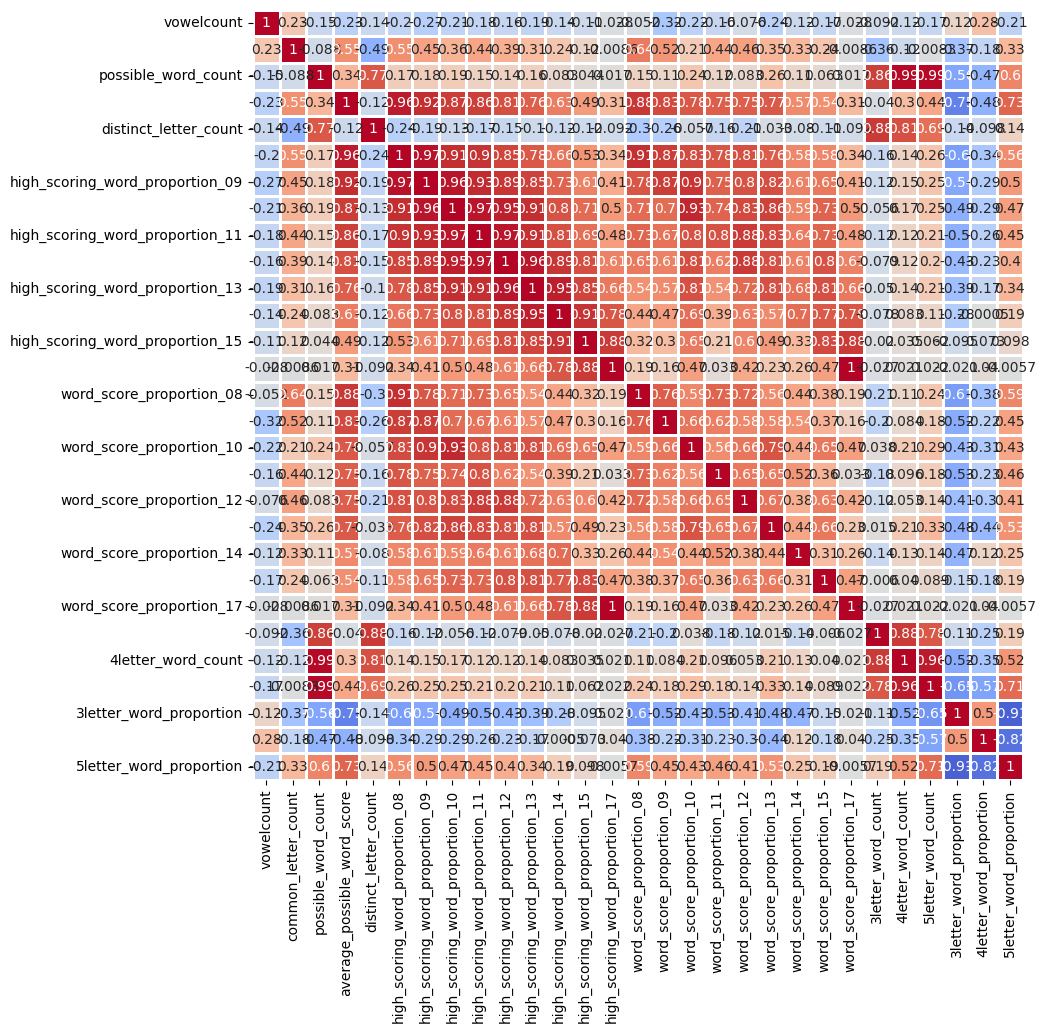

In [21]:
corr_matrix_all = df.corr(numeric_only=True)

# Round the correlation matrix to 2 decimal places
corr_matrix_rounded_all = corr_matrix_all.round(4)

sns.heatmap(corr_matrix_rounded_all, 
            annot=True,      # Display correlation values inside the heatmap cells.
            vmin=-1, vmax=1, # Define the limits of the color scale
            square=True,     # Make sure cells stay square
            #xticklabels=list(df.columns),
            cmap="coolwarm", # Set the color map
            linewidths=1,    # Lines between the cells
            cbar=False
            )
fig = plt.gcf()
fig.set_size_inches( 13, 10)
plt.show()


In [22]:
corr_matrix = df.corrwith(dayScores["scores"])

# Round the correlation matrix to 2 decimal places
corr_matrix_rounded = corr_matrix.round(2)


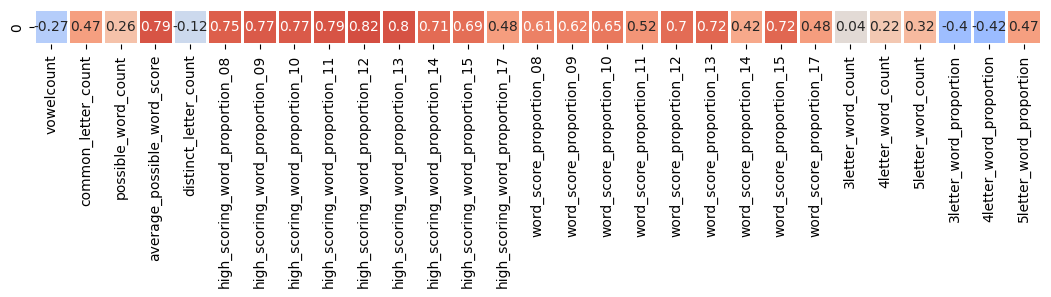

In [23]:
sns.heatmap([corr_matrix_rounded], 
            annot=True,      # Display correlation values inside the heatmap cells.
            vmin=-1, vmax=1, # Define the limits of the color scale
            square=True,     # Make sure cells stay square
            xticklabels=list(df.columns),
            cmap="coolwarm", # Set the color map
            linewidths=1,    # Lines between the cells
            cbar=False
            )
fig = plt.gcf()
fig.set_size_inches( 13, 10)
plt.show()


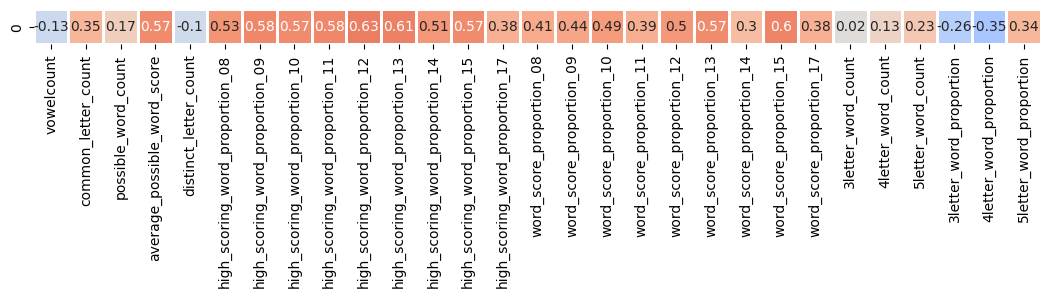

In [24]:
corr_matrix = df.corrwith(dayScores["scores"], method="kendall")
corr_matrix_rounded = corr_matrix.round(2)

sns.heatmap([corr_matrix_rounded], 
            annot=True,      # Display correlation values inside the heatmap cells.
            vmin=-1, vmax=1, # Define the limits of the color scale
            square=True,     # Make sure cells stay square
            xticklabels=list(df.columns),
            cmap="coolwarm", # Set the color map
            linewidths=1,    # Lines between the cells
            cbar=False
            )
fig = plt.gcf()
fig.set_size_inches( 13, 10)
plt.show()


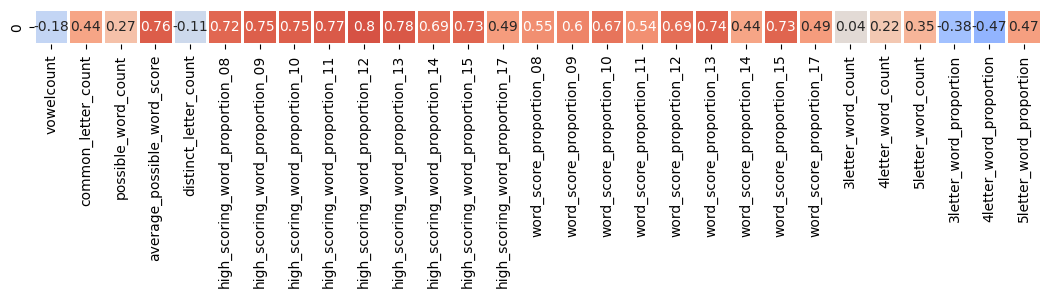

In [25]:
corr_matrix = df.corrwith(dayScores["scores"], method="spearman")
corr_matrix_rounded = corr_matrix.round(2)

sns.heatmap([corr_matrix_rounded], 
            annot=True,      # Display correlation values inside the heatmap cells.
            vmin=-1, vmax=1, # Define the limits of the color scale
            square=True,     # Make sure cells stay square
            xticklabels=list(df.columns),
            cmap="coolwarm", # Set the color map
            linewidths=1,    # Lines between the cells
            cbar=False
            )
fig = plt.gcf()
fig.set_size_inches( 13, 10)
plt.show()


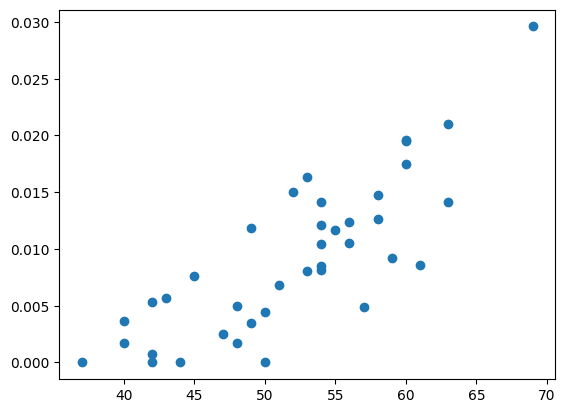

In [26]:
plt.scatter(dayScores["scores"], df['high_scoring_word_proportion_12'])
plt.show()


In [27]:
print(scipy.stats.spearmanr(dayScores["scores"], df['high_scoring_word_proportion_12']))

SignificanceResult(statistic=np.float64(0.8017152148500787), pvalue=np.float64(8.608718556562428e-10))


In [28]:
new_data_stats = get_new_data_stats("lsaelawkeumelaawwfianuwet")
todaydate = "31/08/2026"
actual = 43

In [29]:
model_measures = { "name": [], "selectedDatePrediction": [], "selectedDatePredictionDiff": [], "allPredictions": [], "overallMeanPredictionDiff": [], "overallStDevPredictionDiff": [], "meanSquaredError": [], "r2Score": []}

[48.88338432]


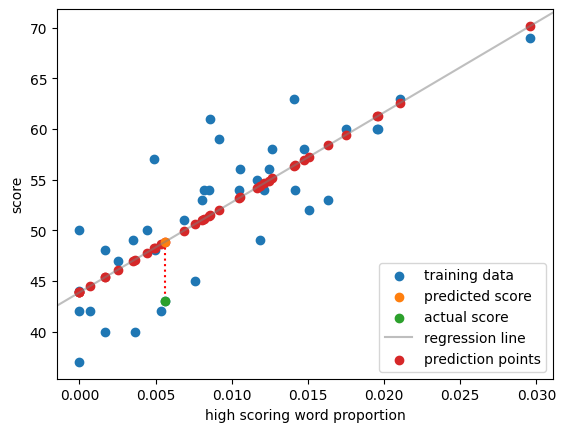

In [30]:
x = dayScores["scores"]
y = df['high_scoring_word_proportion_12'].values.reshape((-1, 1))

model1 = LinearRegression()
model1.fit(y, x)

model1_selected_features = new_data_stats['high_scoring_word_proportion_12']

result1 = model1.predict(np.array(model1_selected_features).reshape(1, -1))
print(result1)

plt.scatter(df['high_scoring_word_proportion_12'], dayScores["scores"], label="training data",zorder=0)

plt.scatter(model1_selected_features, result1, label="predicted score", zorder=2)
plt.scatter(model1_selected_features, actual, label="actual score", zorder=2)

plt.plot([model1_selected_features, model1_selected_features], [result1[0],actual], ':r', zorder=1)

plt.axline((0, model1.intercept_), slope=model1.coef_[0], color='C7', alpha=0.5, label='regression line')

predictions = model1.predict(y)
plt.scatter(df['high_scoring_word_proportion_12'], predictions, label="prediction points", zorder=1)

plt.legend()
plt.xlabel("high scoring word proportion")
plt.ylabel("score")
plt.show()

model_measures["name"].append("model1 (linear regression)")
model_measures["allPredictions"].append(predictions)
model_measures["selectedDatePrediction"].append(result1[0])
model_measures["selectedDatePredictionDiff"].append(abs(result1[0] - actual))

diffs = []
for i in range(len(predictions)):
    diffs.append(abs(predictions[i] - dayScores["scores"][i]))

model_measures["overallMeanPredictionDiff"].append(np.mean(diffs))
model_measures["overallStDevPredictionDiff"].append(np.std(diffs))
model_measures["meanSquaredError"].append(mean_squared_error(dayScores["scores"], predictions))
model_measures["r2Score"].append(r2_score(dayScores["scores"], predictions))

testing out polynomial regression instead of just linear:

[49.05311497]


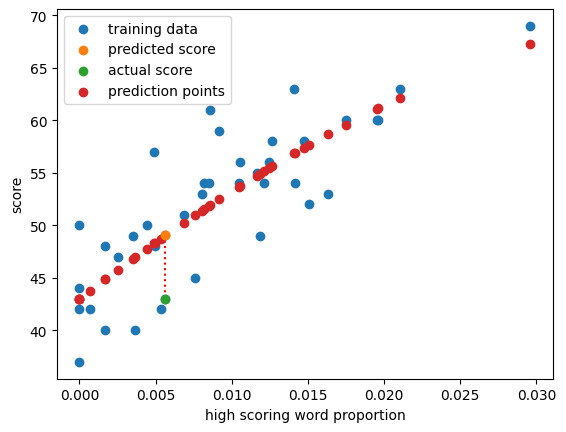

In [31]:
y_ = PolynomialFeatures(degree=2, include_bias=False).fit_transform(y)

model2 = LinearRegression().fit(y_, x)

plt.scatter(df['high_scoring_word_proportion_12'], dayScores["scores"], label="training data",zorder=0)

model2_selected_features = new_data_stats['high_scoring_word_proportion_12']

new_data_stats_transformed = PolynomialFeatures(degree=2, include_bias=False).fit_transform(np.array(model2_selected_features).reshape(1, -1))
result2 = model2.predict(new_data_stats_transformed)
print(result2)

plt.scatter(model2_selected_features, result2, label="predicted score", zorder=2)
plt.scatter(model2_selected_features, actual, label="actual score", zorder=2)

plt.plot([model2_selected_features, model2_selected_features], [result2[0],actual], ':r', zorder=1)

predictions2 = model2.predict(y_)
plt.scatter(df['high_scoring_word_proportion_12'], predictions2, label="prediction points", zorder=1)

plt.legend()
plt.xlabel("high scoring word proportion")
plt.ylabel("score")
plt.show()

model_measures["name"].append("model2 (poly regression)")
model_measures["allPredictions"].append(predictions2)
model_measures["selectedDatePrediction"].append(result2[0])
model_measures["selectedDatePredictionDiff"].append(abs(result2[0] - actual))

diffs = []
for i in range(len(predictions2)):
    diffs.append(abs(predictions2[i] - dayScores["scores"][i]))

model_measures["overallMeanPredictionDiff"].append(np.mean(diffs))
model_measures["overallStDevPredictionDiff"].append(np.std(diffs))
model_measures["meanSquaredError"].append(mean_squared_error(dayScores["scores"], predictions2))
model_measures["r2Score"].append(r2_score(dayScores["scores"], predictions2))

[46.72321207]


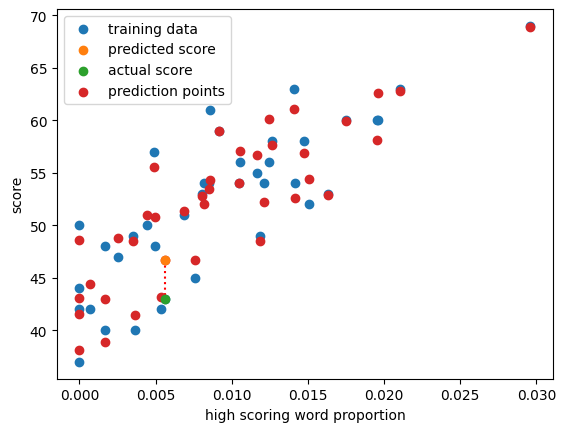

In [32]:
selected_features3 = ['high_scoring_word_proportion_12', 'common_letter_count', 'average_possible_word_score', "word_score_proportion_08","word_score_proportion_09","word_score_proportion_10","word_score_proportion_12","word_score_proportion_13","word_score_proportion_15","word_score_proportion_17"]
y3 = df[selected_features3]

y3_ = PolynomialFeatures( include_bias=False).fit_transform(y3)

model3 = LinearRegression()
model3.fit(y3_, x)


model3_selected_features = new_data_stats[selected_features3]

plt.scatter(df['high_scoring_word_proportion_12'], dayScores["scores"], label="training data",zorder=0)

predict_data_source3_ = PolynomialFeatures( include_bias=False).fit_transform(model3_selected_features)#.reshape(1, -1)
result3 = model3.predict(predict_data_source3_)
print(result3)

plt.scatter(model3_selected_features['high_scoring_word_proportion_12'], result3, label="predicted score", zorder=2)
plt.scatter(model3_selected_features['high_scoring_word_proportion_12'], actual, label="actual score", zorder=2)

plt.plot([model3_selected_features['high_scoring_word_proportion_12'], model3_selected_features['high_scoring_word_proportion_12']], [result3[0],actual], ':r', zorder=1)

predictions3 = model3.predict(y3_)
plt.scatter(df['high_scoring_word_proportion_12'], predictions3, label="prediction points", zorder=1)

plt.legend()
plt.xlabel("high scoring word proportion")
plt.ylabel("score")
plt.show()

model_measures["name"].append("model3 (poly regression, word score proportion focus)")
model_measures["allPredictions"].append(predictions3)
model_measures["selectedDatePrediction"].append(result3[0])
model_measures["selectedDatePredictionDiff"].append(abs(result3[0] - actual))

diffs = []
for i in range(len(predictions3)):
    diffs.append(abs(predictions3[i] - dayScores["scores"][i]))

model_measures["overallMeanPredictionDiff"].append(np.mean(diffs))
model_measures["overallStDevPredictionDiff"].append(np.std(diffs))
model_measures["meanSquaredError"].append(mean_squared_error(dayScores["scores"], predictions3))
model_measures["r2Score"].append(r2_score(dayScores["scores"], predictions3))

selected_features4 = ['3letter_word_proportion', '4letter_word_proportion', '5letter_word_proportion']
y4 = df[selected_features4]

y4_ = PolynomialFeatures(degree=2, include_bias=False).fit_transform(y4)

model4 = LinearRegression()
model4.fit(y4_, x)

model4_selected_features = new_data_stats[selected_features4]

plt.scatter(df['5letter_word_proportion'], dayScores["scores"], label="training data",zorder=0)

predict_data_source4_ = PolynomialFeatures(degree=2, include_bias=False).fit_transform(model4_selected_features)#.reshape(1, -1)
result4 = model4.predict(predict_data_source4_)
print(result4)

plt.scatter(model4_selected_features['5letter_word_proportion'], result4, label="predicted score", zorder=2)
plt.scatter(model4_selected_features['5letter_word_proportion'], actual, label="actual score", zorder=2)

plt.plot([model4_selected_features['5letter_word_proportion'], model4_selected_features['5letter_word_proportion']], [result4[0],actual], ':r', zorder=1)

predictions4 = model4.predict(y4_)
plt.scatter(df['5letter_word_proportion'], predictions4, label="prediction points", zorder=1)

plt.legend()
plt.xlabel("5letter_word_proportion")
plt.ylabel("score")
plt.show()

model_measures["name"].append("model4 (poly regression, word length proportion focus)")
model_measures["allPredictions"].append(predictions4)
model_measures["selectedDatePrediction"].append(result4[0])
model_measures["selectedDatePredictionDiff"].append(abs(result4[0] - actual))

diffs = []
for i in range(len(predictions4)):
    diffs.append(abs(predictions4[i] - dayScores["scores"][i]))

model_measures["overallMeanPredictionDiff"].append(np.mean(diffs))
model_measures["overallStDevPredictionDiff"].append(np.std(diffs))
model_measures["meanSquaredError"].append(mean_squared_error(dayScores["scores"], predictions4))
model_measures["r2Score"].append(r2_score(dayScores["scores"], predictions4))

[49.77055271]


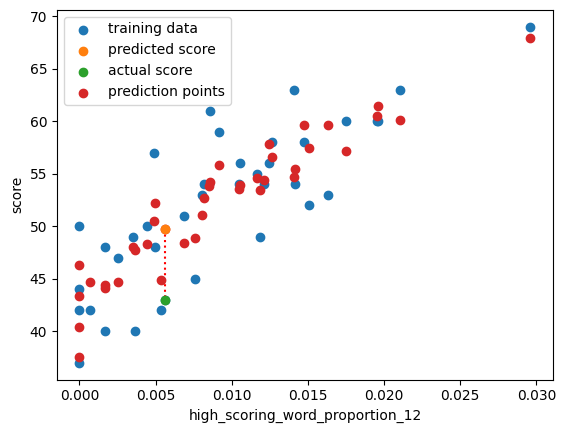

In [33]:
selected_features5 = ['high_scoring_word_proportion_12', 'average_possible_word_score', 'common_letter_count', '5letter_word_proportion']
y5 = df[selected_features5]

y5_ = PolynomialFeatures(degree=2, include_bias=False).fit_transform(y5)

model5 = LinearRegression()
model5.fit(y5_, x)

model5_selected_features = new_data_stats[selected_features5]

plt.scatter(df['high_scoring_word_proportion_12'], dayScores["scores"], label="training data",zorder=0)

predict_data_source5_ = PolynomialFeatures(degree=2, include_bias=False).fit_transform(model5_selected_features)#.reshape(1, -1)
result5 = model5.predict(predict_data_source5_)
print(result5)

plt.scatter(model5_selected_features['high_scoring_word_proportion_12'], result5, label="predicted score", zorder=2)
plt.scatter(model5_selected_features['high_scoring_word_proportion_12'], actual, label="actual score", zorder=2)

plt.plot([model5_selected_features['high_scoring_word_proportion_12'], model5_selected_features['high_scoring_word_proportion_12']], [result5[0],actual], ':r', zorder=1)

predictions5 = model5.predict(y5_)
plt.scatter(df['high_scoring_word_proportion_12'], predictions5, label="prediction points", zorder=1)

plt.legend()
plt.xlabel("high_scoring_word_proportion_12")
plt.ylabel("score")
plt.show()

model_measures["name"].append("model5 (poly regression, high correlation focus)")
model_measures["allPredictions"].append(predictions5)
model_measures["selectedDatePrediction"].append(result5[0])
model_measures["selectedDatePredictionDiff"].append(abs(result5[0] - actual))

diffs = []
for i in range(len(predictions5)):
    diffs.append(abs(predictions5[i] - dayScores["scores"][i]))

model_measures["overallMeanPredictionDiff"].append(np.mean(diffs))
model_measures["overallStDevPredictionDiff"].append(np.std(diffs))
model_measures["meanSquaredError"].append(mean_squared_error(dayScores["scores"], predictions5))
model_measures["r2Score"].append(r2_score(dayScores["scores"], predictions5))

[50.22642483]


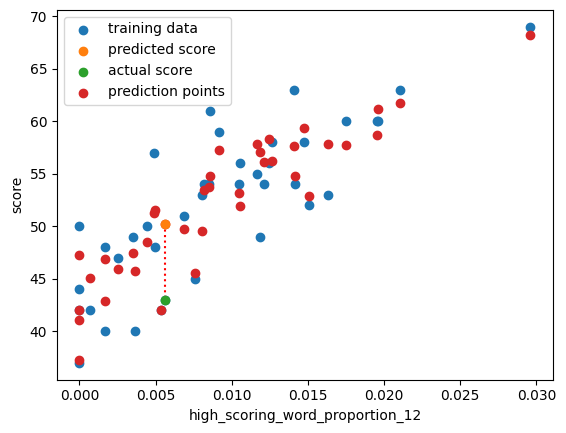

In [34]:
selected_features4 = ['high_scoring_word_proportion_12', 'average_possible_word_score', 'common_letter_count', '5letter_word_proportion', "distinct_letter_count"]
y4 = df[selected_features4]

y4_ = PolynomialFeatures(degree=2, include_bias=False).fit_transform(y4)

model4 = LinearRegression()
model4.fit(y4_, x)

model4_selected_features = new_data_stats[selected_features4]

plt.scatter(df['high_scoring_word_proportion_12'], dayScores["scores"], label="training data",zorder=0)

predict_data_source4_ = PolynomialFeatures(degree=2, include_bias=False).fit_transform(model4_selected_features)#.reshape(1, -1)
result4 = model4.predict(predict_data_source4_)
print(result4)

plt.scatter(model4_selected_features['high_scoring_word_proportion_12'], result4, label="predicted score", zorder=2)
plt.scatter(model4_selected_features['high_scoring_word_proportion_12'], actual, label="actual score", zorder=2)

plt.plot([model4_selected_features['high_scoring_word_proportion_12'], model4_selected_features['high_scoring_word_proportion_12']], [result4[0],actual], ':r', zorder=1)

predictions4 = model4.predict(y4_)
plt.scatter(df['high_scoring_word_proportion_12'], predictions4, label="prediction points", zorder=1)

plt.legend()
plt.xlabel("high_scoring_word_proportion_12")
plt.ylabel("score")
plt.show()

model_measures["name"].append("model4 (poly regression, high correlation focus + 1)")
model_measures["allPredictions"].append(predictions4)
model_measures["selectedDatePrediction"].append(result4[0])
model_measures["selectedDatePredictionDiff"].append(abs(result4[0] - actual))

diffs = []
for i in range(len(predictions4)):
    diffs.append(abs(predictions4[i] - dayScores["scores"][i]))

model_measures["overallMeanPredictionDiff"].append(np.mean(diffs))
model_measures["overallStDevPredictionDiff"].append(np.std(diffs))
model_measures["meanSquaredError"].append(mean_squared_error(dayScores["scores"], predictions4))
model_measures["r2Score"].append(r2_score(dayScores["scores"], predictions4))

[48.72653881]


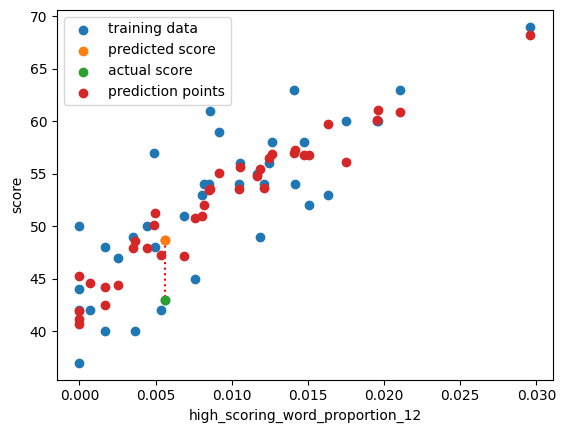

In [35]:

selected_features6 = ['high_scoring_word_proportion_12', 'average_possible_word_score', 'common_letter_count', '5letter_word_proportion']
y6 = df[selected_features6]

#y6_ = PolynomialFeatures(degree=2, include_bias=False).fit_transform(y6)

model6 = LinearRegression()
model6.fit(y6, x)

model6_selected_features = new_data_stats[selected_features6]

plt.scatter(df['high_scoring_word_proportion_12'], dayScores["scores"], label="training data",zorder=0)

#predict_data_source6_ = PolynomialFeatures(degree=2, include_bias=False).fit_transform(model6_selected_features)#.reshape(1, -1)
result6 = model6.predict(model6_selected_features)
print(result6)

plt.scatter(model6_selected_features['high_scoring_word_proportion_12'], result6, label="predicted score", zorder=2)
plt.scatter(model6_selected_features['high_scoring_word_proportion_12'], actual, label="actual score", zorder=2)

plt.plot([model6_selected_features['high_scoring_word_proportion_12'], model6_selected_features['high_scoring_word_proportion_12']], [result6[0],actual], ':r', zorder=1)

predictions6 = model6.predict(y6)
plt.scatter(df['high_scoring_word_proportion_12'], predictions6, label="prediction points", zorder=1)

plt.legend()
plt.xlabel("high_scoring_word_proportion_12")
plt.ylabel("score")
plt.show()

model_measures["name"].append("model6 (linear regression, high correlation focus)")
model_measures["allPredictions"].append(predictions6)
model_measures["selectedDatePrediction"].append(result6[0])
model_measures["selectedDatePredictionDiff"].append(abs(result6[0] - actual))

diffs = []
for i in range(len(predictions6)):
    diffs.append(abs(predictions6[i] - dayScores["scores"][i]))

model_measures["overallMeanPredictionDiff"].append(np.mean(diffs))
model_measures["overallStDevPredictionDiff"].append(np.std(diffs))
model_measures["meanSquaredError"].append(mean_squared_error(dayScores["scores"], predictions6))
model_measures["r2Score"].append(r2_score(dayScores["scores"], predictions6))

In [36]:
def model7_predict(other_predictions):
    total_other_predictions = 0
    for m in range(len(other_predictions)):
        total_other_predictions += other_predictions[m]
    
    return total_other_predictions / len(other_predictions)

[np.float64(48.89720461795026)]
range(0, 39)


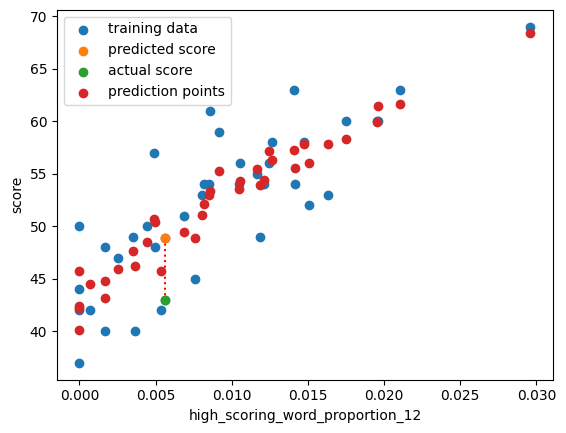

In [37]:
plt.scatter(df['high_scoring_word_proportion_12'], dayScores["scores"], label="training data",zorder=0)

total_other_predictions = 0
for m in range(len(model_measures['selectedDatePrediction'])):
    total_other_predictions += model_measures['selectedDatePrediction'][m]

result7 = [total_other_predictions / len(model_measures['selectedDatePrediction'])]
print(result7)

plt.scatter(new_data_stats['high_scoring_word_proportion_12'], result7, label="predicted score", zorder=2)
plt.scatter(new_data_stats['high_scoring_word_proportion_12'], actual, label="actual score", zorder=2)

plt.plot([new_data_stats['high_scoring_word_proportion_12'], new_data_stats['high_scoring_word_proportion_12']], [result7[0],actual], ':r', zorder=1)

predictions7 = []
print(range(len(df['high_scoring_word_proportion_12'])))
for d in range(len(df['high_scoring_word_proportion_12'])):
    other_predictions = []
    for i in range(6):
        other_predictions.append(model_measures['allPredictions'][i][d])
    predictions7.append(model7_predict(other_predictions))

plt.scatter(df['high_scoring_word_proportion_12'], predictions7, label="prediction points", zorder=1)

plt.legend()
plt.xlabel("high_scoring_word_proportion_12")
plt.ylabel("score")
plt.show()

model_measures["name"].append("model7 (average of first 6 models)")
model_measures["selectedDatePrediction"].append(result7[0])
model_measures["selectedDatePredictionDiff"].append(abs(result7[0] - actual))

diffs = []
for i in range(len(predictions7)):
    diffs.append(abs(predictions7[i] - dayScores["scores"][i]))

model_measures["allPredictions"].append(predictions7)
model_measures["overallMeanPredictionDiff"].append(np.mean(diffs))
model_measures["overallStDevPredictionDiff"].append(np.std(diffs))
model_measures["meanSquaredError"].append(mean_squared_error(dayScores["scores"], predictions7))
model_measures["r2Score"].append(r2_score(dayScores["scores"], predictions7))

In [38]:
def model8_predict(other_predictions):
    daily_model_prediction_range.append(max(other_predictions) - min(other_predictions))
    
    other_predictions_mean = np.mean(other_predictions)
    
    other_predictions_abs_mean_diffs = [None,None,None,None,None,None]
    for i in range(6):
        other_predictions_abs_mean_diffs[i] = abs(other_predictions[i] - other_predictions_mean)
    
    sorted_other_predictions_abs_mean_diffs = sorted(other_predictions_abs_mean_diffs)
    
    mult_indexes = [None,None,None,None,None,None]
    for i in range(6):
        mult_indexes[i] = sorted_other_predictions_abs_mean_diffs.index(other_predictions_abs_mean_diffs[i])
    
    indexed_diff_multipliers = [None,None,None,None,None,None]
    for i in range(6):
        indexed_diff_multipliers[i] = diff_multipliers[mult_indexes[i]]
    
    
    other_predictions_weighted_sum = 0
    for i in range(6):
        other_predictions_weighted_sum += other_predictions[i] * indexed_diff_multipliers[i]
    
    return other_predictions_weighted_sum / 6

[np.float64(48.883384319750235), np.float64(49.05311497097644), np.float64(46.7232120716825), np.float64(49.770552705875275), np.float64(50.22642483335176), np.float64(48.726538806065385)]
48.89720461795026
[np.float64(0.013820298200023728), np.float64(0.1559103530261794), np.float64(2.173992546267762), np.float64(0.8733480879250166), np.float64(1.3292202154014987), np.float64(0.17066581188487362)]
[np.float64(0.013820298200023728), np.float64(0.1559103530261794), np.float64(0.17066581188487362), np.float64(0.8733480879250166), np.float64(1.3292202154014987), np.float64(2.173992546267762)]
[0, 1, 5, 3, 4, 2]
[1.5, 1.3, 0.5, 0.9, 0.7, 1.1]
294.0069194830419
result
[np.float64(49.00115324717365)]


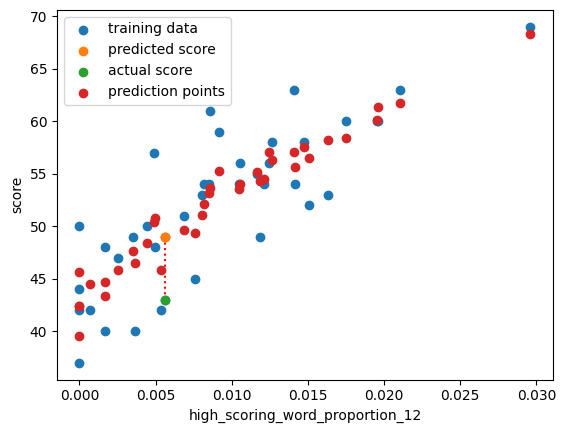

In [39]:
plt.scatter(df['high_scoring_word_proportion_12'], dayScores["scores"], label="training data",zorder=0)

other_predictions = [None,None,None,None,None,None]
for i in range(6):
    other_predictions[i] = model_measures['selectedDatePrediction'][i]

other_predictions_mean = np.mean(other_predictions)

other_predictions_abs_mean_diffs = [None,None,None,None,None,None]
for i in range(6):
    other_predictions_abs_mean_diffs[i] = abs(other_predictions[i] - other_predictions_mean)

sorted_other_predictions_abs_mean_diffs = sorted(other_predictions_abs_mean_diffs)

mult_indexes = [None,None,None,None,None,None]
for i in range(6):
    mult_indexes[i] = sorted_other_predictions_abs_mean_diffs.index(other_predictions_abs_mean_diffs[i])

diff_multipliers = [1.5, 1.3, 1.1, 0.9, 0.7, 0.5]

indexed_diff_multipliers = [None,None,None,None,None,None]
for i in range(6):
    indexed_diff_multipliers[i] = diff_multipliers[mult_indexes[i]]


other_predictions_weighted_sum = 0
for i in range(6):
    other_predictions_weighted_sum += other_predictions[i] * indexed_diff_multipliers[i]

print(other_predictions)
print(other_predictions_mean)
print(other_predictions_abs_mean_diffs)
print(sorted_other_predictions_abs_mean_diffs)
print(mult_indexes)
print(indexed_diff_multipliers)
print(other_predictions_weighted_sum)

result8 = [other_predictions_weighted_sum / 6]
print("result")
print(result8)

plt.scatter(new_data_stats['high_scoring_word_proportion_12'], result8, label="predicted score", zorder=2)
plt.scatter(new_data_stats['high_scoring_word_proportion_12'], actual, label="actual score", zorder=2)

plt.plot([new_data_stats['high_scoring_word_proportion_12'], new_data_stats['high_scoring_word_proportion_12']], [result8[0],actual], ':r', zorder=1)

daily_model_prediction_range = []
predictions8 = []
for d in range(len(df['high_scoring_word_proportion_12'])):
    #total_other_predictions = 0
    #for m in range(6):
    #    total_other_predictions += model_measures['allPredictions'][m][d]
    
    other_predictions = [None,None,None,None,None,None]
    for i in range(6):
        other_predictions[i] = model_measures['allPredictions'][i][d]
    
    predictions8.append(model8_predict(other_predictions))

    
plt.scatter(df['high_scoring_word_proportion_12'], predictions8, label="prediction points", zorder=1)

plt.legend()
plt.xlabel("high_scoring_word_proportion_12")
plt.ylabel("score")
plt.show()

model_measures["name"].append("model8 (weighted average of first 6 models)")
model_measures["selectedDatePrediction"].append(result8[0])
model_measures["selectedDatePredictionDiff"].append(abs(result8[0] - actual))

diffs = []
for i in range(len(predictions8)):
    diffs.append(abs(predictions8[i] - dayScores["scores"][i]))

model_measures["allPredictions"].append(predictions8)
model_measures["overallMeanPredictionDiff"].append(np.mean(diffs))
model_measures["overallStDevPredictionDiff"].append(np.std(diffs))
model_measures["meanSquaredError"].append(mean_squared_error(dayScores["scores"], predictions8))
model_measures["r2Score"].append(r2_score(dayScores["scores"], predictions8))

                                                name  selectedDatePrediction  \
0                         model1 (linear regression)               48.883384   
1                           model2 (poly regression)               49.053115   
2  model3 (poly regression, word score proportion...               46.723212   
3   model5 (poly regression, high correlation focus)               49.770553   
4  model4 (poly regression, high correlation focu...               50.226425   
5  model6 (linear regression, high correlation fo...               48.726539   
6                 model7 (average of first 6 models)               48.897205   
7        model8 (weighted average of first 6 models)               49.001153   

   selectedDatePredictionDiff  \
0                    5.883384   
1                    6.053115   
2                    3.723212   
3                    6.770553   
4                    7.226425   
5                    5.726539   
6                    5.897205   
7              

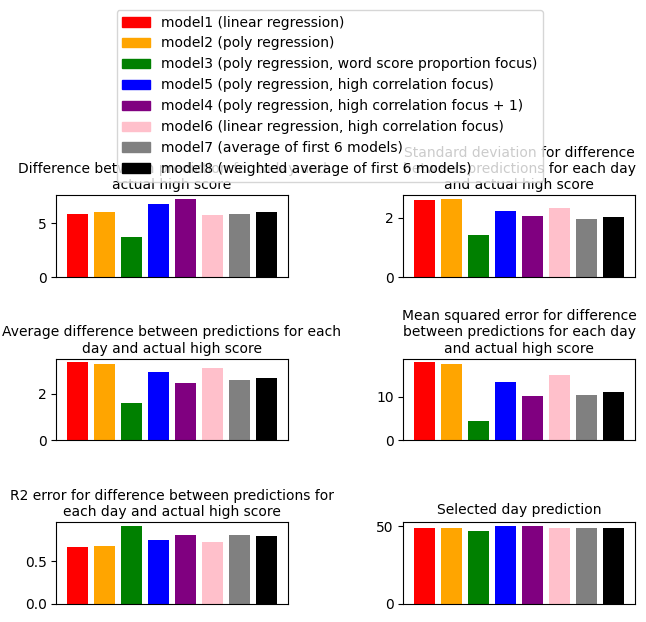

In [40]:
model_prediction_info = pd.DataFrame(model_measures)

print(model_prediction_info)
colors = ["red", "orange", "green", "blue", "purple", "pink", "grey", "black"]

fig, axs = plt.subplots(3, 2)

axs[0,0].bar(model_prediction_info["name"], model_prediction_info["selectedDatePredictionDiff"], color=colors)

axs[0,0].set_title("Difference between prediction for today and actual high score", fontsize=10, wrap=True)
#axs[0,0].set_xlabel("Model")
#axs[0,0].set_ylabel("Difference")
axs[0,0].set_xticks([])
#axs[0,0].tick_params('x', labelrotation=90) 

axs[1,0].bar(model_prediction_info["name"], model_prediction_info["overallMeanPredictionDiff"], color=colors)

axs[1,0].set_title("Average difference between predictions for each day and actual high score", fontsize=10, wrap=True)
#axs[1,0].set_xlabel("Model")
#axs[1,0].set_ylabel("Difference")
axs[1,0].set_xticks([])
#axs[1,0].tick_params('x', labelrotation=90) 

axs[0,1].bar(model_prediction_info["name"], model_prediction_info["overallStDevPredictionDiff"], color=colors)

axs[0,1].set_title("Standard deviation for difference between predictions for each day and actual high score", fontsize=10, wrap=True)
#axs[0,1].set_xlabel("Model")
#axs[0,1].set_ylabel("Difference")
axs[0,1].set_xticks([])
#axs[0,1].tick_params('x', labelrotation=90) 

axs[1,1].bar(model_prediction_info["name"], model_prediction_info["meanSquaredError"], color=colors)

axs[1,1].set_title("Mean squared error for difference between predictions for each day and actual high score", fontsize=10, wrap=True)
#axs[1,1].set_xlabel("Model")
#axs[1,1].set_ylabel("Difference")
axs[1,1].set_xticks([])
#axs[1,1].tick_params('x', labelrotation=90) 

axs[2,0].bar(model_prediction_info["name"], model_prediction_info["r2Score"], color=colors)

axs[2,0].set_title("R2 error for difference between predictions for each day and actual high score", fontsize=10, wrap=True)
#axs[2,0].set_xlabel("Model")
#axs[2,0].set_ylabel("Difference")
axs[2,0].set_xticks([])
#axs[2,0].tick_params('x', labelrotation=90) 

axs[2,1].bar(model_prediction_info["name"], model_prediction_info["selectedDatePrediction"], color=colors)

axs[2,1].set_title("Selected day prediction", fontsize=10, wrap=True)
#axs[2,0].set_xlabel("Model")
#axs[2,0].set_ylabel("Difference")
axs[2,1].set_xticks([])

#handles, labels = axs[0,0].get_legend_handles_labels()
#fig.legend(handles, labels, loc='upper center')
#axs[0,0].get_legend().remove()
#fig.legend(handles=colors, labels=model_measures["name"])

patches = []

for i in range(len(colors)):
    patches.append(mpatches.Patch(color=colors[i], label=model_measures["name"][i]))

fig.legend(bbox_to_anchor=(0.5, 1.3), handles=patches, loc='upper center')
fig.tight_layout()
fig.subplots_adjust(wspace=0.5,hspace=1)

In [41]:
scoreObj["dates"].append(todaydate)
scoreObj["scores"].append(actual)

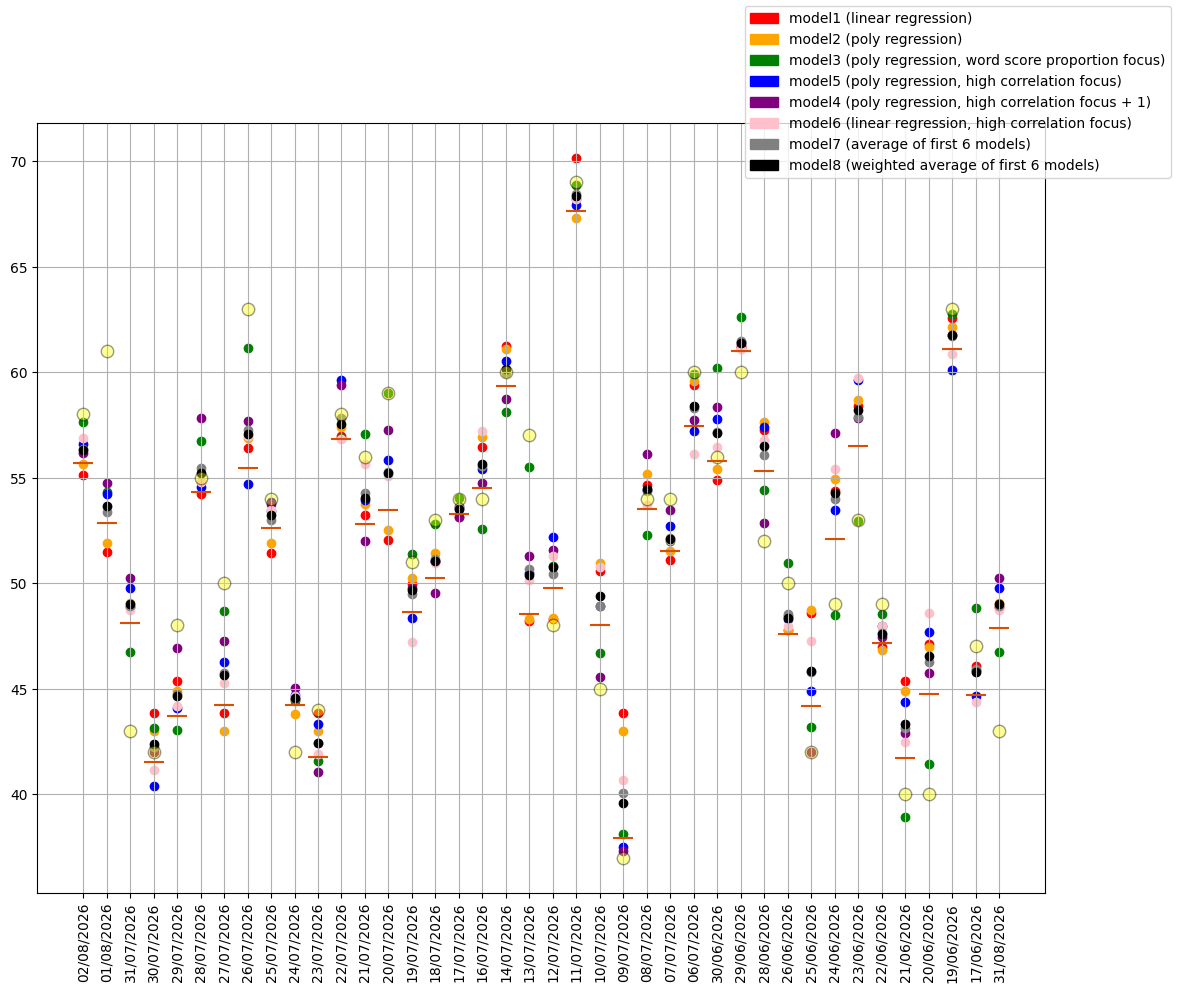

In [42]:
fig = plt.figure()

plt.scatter(scoreObj["dates"], scoreObj["scores"], s=80, zorder=3, color='yellow',edgecolors='black', alpha=0.4)
for i in range(len(model_measures["allPredictions"])):
    ps = model_measures["allPredictions"][i]
    ps = np.append(ps, model_measures["selectedDatePrediction"][i])
    plt.scatter(scoreObj["dates"], ps, color=colors[i])


other_newdata_predictions = [None,None,None,None,None,None]
for i in range(6):
    other_newdata_predictions[i] = model_measures['allPredictions'][i][-1]

daily_model_prediction_range.append(max(other_newdata_predictions) - min(other_newdata_predictions))

model8_minus_quarter_range_list = []
model8_predictions = model_measures["allPredictions"][-1]
model8_predictions = np.append(model8_predictions, model_measures["selectedDatePrediction"][-1])
for i in range(len(model8_predictions)):
    model8_minus_quarter_range_list.append(model8_predictions[i] - daily_model_prediction_range[i] * 0.25)

plt.scatter(scoreObj["dates"], model8_minus_quarter_range_list, color="xkcd:deep orange", marker="_", zorder=5, s=200)


plt.grid(visible=True)
plt.xticks(rotation=90)

fig.set_size_inches( 13, 10)
fig.legend(handles=patches, loc='upper right')

plt.show()

In [43]:
for i in range(len(model_measures["allPredictions"])):
    print("-------------------------------------\n")
    print("model: " + model_measures["name"][i])
    print("average prediction diff: " + str(model_measures["overallMeanPredictionDiff"][i]))
    print()
    biggest_negative_diff = 100
    biggest_positive_diff = -100
    for j in range(len(model_measures["allPredictions"][i])):
        p = model_measures["allPredictions"][i][j]
        diff = p - scoreObj["scores"][j]
        print(str(p) + " \t" + str(scoreObj["scores"][j]) + " \t" + str(diff))
        if diff < biggest_negative_diff:
            biggest_negative_diff = diff
        if diff > biggest_positive_diff:
            biggest_positive_diff = diff
    print()
    print("biggest positive diff: " + str(biggest_positive_diff))
    print("biggest negative diff: " + str(biggest_negative_diff))
    print("today diff: " + str(model_measures["selectedDatePredictionDiff"][i]))
    print()

#model_measures = { "name": [], 
#                   "selectedDatePrediction": [],
#                   "selectedDatePredictionDiff": [], 
#                   "allPredictions": [], 
#                   "overallMeanPredictionDiff": [], 
#                   "overallStDevPredictionDiff": [], 
#                   "meanSquaredError": [],
#                   "r2Score": []}

-------------------------------------

model: model1 (linear regression)
average prediction diff: 3.3275179296166355

55.110831693155035 	58 	-2.889168306844965
51.474049235675906 	61 	-9.525950764324094
48.883384319750235 	43 	5.883384319750235
43.86329919220963 	42 	1.863299192209631
45.38046777657165 	48 	-2.619532223428351
54.21826945806337 	55 	-0.781730541936632
43.86329919220963 	50 	-6.136700807790369
56.388536463162936 	63 	-6.611463536837064
51.444827072539724 	54 	-2.5551729274602764
44.48992476877852 	42 	2.489924768778522
43.86329919220963 	44 	-0.13670080779036908
56.9701643802391 	58 	-1.0298356197609024
53.23500722200198 	56 	-2.7649927779980175
52.031238093093165 	59 	-6.968761906906835
49.95764121947086 	51 	-1.0423587805291419
51.01368868449521 	53 	-1.9863113155047927
53.143247678629336 	54 	-0.8567523213706636
56.455268726539764 	54 	2.4552687265397637
61.23728096042977 	60 	1.2372809604297714
48.21896128816398 	57 	-8.781038711836018
48.288864000273925 	48 	0.2888

# Prediction outputting starts here!

In [44]:
data_to_predict = pd.read_json('letter_sets_2026-08-03-2027-08-01.json')

print(data_to_predict)

          date                  letterset
0   2026-08-03  sklbgpaesacolkwaeomloeest
1   2026-08-04  ibcevpkgnernagerupgiesnii
2   2026-08-05  iwusdrusslbsolonoygeitigy
3   2026-08-06  iipsbnfayiottytfneraomede
4   2026-08-07  ehyhorclonaasuecklsoadirh
..         ...                        ...
335 2027-08-28  lutulseaiatdekeiphdenuskh
336 2027-08-29  ieeuwyoolmklmriyosaskslpa
337 2027-08-30  nyysmupbrnyasuoctrauatsec
338 2027-08-31  egdmlrepwtivterabcduaonlm
339 2027-08-01  vntpanhepsasgeejsezisgomr

[340 rows x 2 columns]


In [45]:
prediction_data_stats = {}

prediction_data_stats["vowelcount"] = []
prediction_data_stats["common_letter_count"] = []
prediction_data_stats["possible_word_count"] = []
prediction_data_stats["average_possible_word_score"] = []
prediction_data_stats["distinct_letter_count"] = []

prediction_data_stats["high_scoring_word_proportion_08"] = []
prediction_data_stats["high_scoring_word_proportion_09"] = []
prediction_data_stats["high_scoring_word_proportion_10"] = []
prediction_data_stats["high_scoring_word_proportion_11"] = []
prediction_data_stats["high_scoring_word_proportion_12"] = []
prediction_data_stats["high_scoring_word_proportion_13"] = []
prediction_data_stats["high_scoring_word_proportion_14"] = []
prediction_data_stats["high_scoring_word_proportion_15"] = []
prediction_data_stats["high_scoring_word_proportion_17"] = []

prediction_data_stats["word_score_proportion_08"] = []
prediction_data_stats["word_score_proportion_09"] = []
prediction_data_stats["word_score_proportion_10"] = []
prediction_data_stats["word_score_proportion_11"] = []
prediction_data_stats["word_score_proportion_12"] = []
prediction_data_stats["word_score_proportion_13"] = []
prediction_data_stats["word_score_proportion_14"] = []
prediction_data_stats["word_score_proportion_15"] = []
prediction_data_stats["word_score_proportion_17"] = []

prediction_data_stats["3letter_word_count"] = []
prediction_data_stats["4letter_word_count"] = []
prediction_data_stats["5letter_word_count"] = []
prediction_data_stats["3letter_word_proportion"] = []
prediction_data_stats["4letter_word_proportion"] = []
prediction_data_stats["5letter_word_proportion"] = []

for i, daydata in data_to_predict.iterrows():
    scores = get_possible_word_scores(daydata["letterset"])
    numWords = len(scores)
    scoreTotal = print_possible_word_total_stats(scores)
    length_counts = get_word_length_counts(scores)
    word_score_counts = get_word_score_counts(scores)
    
    prediction_data_stats["vowelcount"].append(vowel_count(daydata["letterset"]))
    prediction_data_stats["common_letter_count"].append(count_common_letters(daydata["letterset"]))
    prediction_data_stats["possible_word_count"].append(numWords)
    prediction_data_stats["average_possible_word_score"].append(scoreTotal / numWords)
    prediction_data_stats["distinct_letter_count"].append(get_distinct_letter_count(daydata["letterset"]))
    
    prediction_data_stats["high_scoring_word_proportion_08"].append(get_word_scoring_above_count(word_score_counts, 8) / numWords)
    prediction_data_stats["high_scoring_word_proportion_09"].append(get_word_scoring_above_count(word_score_counts, 9) / numWords)
    prediction_data_stats["high_scoring_word_proportion_10"].append(get_word_scoring_above_count(word_score_counts, 10) / numWords)
    prediction_data_stats["high_scoring_word_proportion_11"].append(get_word_scoring_above_count(word_score_counts, 11) / numWords)
    prediction_data_stats["high_scoring_word_proportion_12"].append(get_word_scoring_above_count(word_score_counts, 12) / numWords)
    prediction_data_stats["high_scoring_word_proportion_13"].append(get_word_scoring_above_count(word_score_counts, 13) / numWords)
    prediction_data_stats["high_scoring_word_proportion_14"].append(get_word_scoring_above_count(word_score_counts, 14) / numWords)
    prediction_data_stats["high_scoring_word_proportion_15"].append(get_word_scoring_above_count(word_score_counts, 15) / numWords)
    prediction_data_stats["high_scoring_word_proportion_17"].append(get_word_scoring_above_count(word_score_counts, 17) / numWords)
    
    prediction_data_stats["word_score_proportion_08"].append(0 if word_score_counts[8] == 0 else word_score_counts[8] / numWords)
    prediction_data_stats["word_score_proportion_09"].append(0 if word_score_counts[9] == 0 else word_score_counts[9] / numWords)
    prediction_data_stats["word_score_proportion_10"].append(0 if word_score_counts[10] == 0 else word_score_counts[10] / numWords)
    prediction_data_stats["word_score_proportion_11"].append(0 if word_score_counts[11] == 0 else word_score_counts[11] / numWords)
    prediction_data_stats["word_score_proportion_12"].append(0 if word_score_counts[12] == 0 else word_score_counts[12] / numWords)
    prediction_data_stats["word_score_proportion_13"].append(0 if word_score_counts[13] == 0 else word_score_counts[13] / numWords)
    prediction_data_stats["word_score_proportion_14"].append(0 if word_score_counts[14] == 0 else word_score_counts[14] / numWords)
    prediction_data_stats["word_score_proportion_15"].append(0 if word_score_counts[15] == 0 else word_score_counts[15] / numWords)
    prediction_data_stats["word_score_proportion_17"].append(0 if word_score_counts[17] == 0 else word_score_counts[17] / numWords)
    
    prediction_data_stats["3letter_word_count"].append(length_counts[3])
    prediction_data_stats["4letter_word_count"].append(length_counts[4])
    prediction_data_stats["5letter_word_count"].append(length_counts[5])
    prediction_data_stats["3letter_word_proportion"].append(length_counts[3] / numWords)
    prediction_data_stats["4letter_word_proportion"].append(length_counts[4] / numWords)
    prediction_data_stats["5letter_word_proportion"].append(length_counts[5] / numWords)

In [46]:
prediction_df = pd.DataFrame(prediction_data_stats)

full_prediction_data = data_to_predict.join(prediction_df)

In [47]:
models = [model1, model2, model3, model4, model5, model6]
model_selected_features = [
    ['high_scoring_word_proportion_12'],
    ['high_scoring_word_proportion_12'],
    selected_features3, 
    selected_features4, 
    selected_features5, 
    selected_features6
]
is_polynomial = [False, True, True, True, True, False]
is_reshape = [True, False, False, False, False, False]

model_predictions = []

for j in range(6):
    features = model_selected_features[j]
    features = full_prediction_data[model_selected_features[j]]
    if is_polynomial[j]:
        transformed = np.array(features)
        if is_reshape[j]:
            transformed = transformed.reshape(1, -1)
        features = PolynomialFeatures(degree=2, include_bias=False).fit_transform(transformed)
    model_predictions.append(models[j].predict(features))

model7_predictions = np.array([])
model8_predictions = np.array([])
for i, row in full_prediction_data.iterrows():
    other_predictions = []
    for j in range(6):
        other_predictions.append(model_predictions[j][i])
    model7_predictions = np.append(model7_predictions, model7_predict(other_predictions))
    model8_predictions = np.append(model8_predictions, model8_predict(other_predictions))

model_predictions.append(model7_predictions)
model_predictions.append(model8_predictions)

/home/bex/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [48]:
import math
import json

final_results = {}

for i in range(len(model_predictions[0])):
    date = data_to_predict["date"][i].strftime("%Y-%m-%d")
    prediction_dict = {}
    
    all_predictions_for_date = []
    for j in range(len(model_predictions)):
        all_predictions_for_date.append(model_predictions[j][i])
    
    prediction_range = max(all_predictions_for_date) - min(all_predictions_for_date)
    prediction_dict["topscore"] = math.floor((model8_predictions[i] - prediction_range * 0.25).item())
    prediction_dict["halfrange"] = math.floor(((prediction_range * 0.5).item()) * 100) / 100
    
    final_results[date] = prediction_dict

with open('target_score_data.json', 'w') as f:
    json.dump(final_results, f)


In [49]:
print(datetime.datetime.now())

2026-08-03 22:20:48.107084
